In [2]:
import MetaTrader5 as terminal
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import talib
import pywt
from numba.core.types import none

In [3]:
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (24, 16)

In [4]:
def init(terminal_path='C:/demoalfaforex/terminal64.exe'):
    if terminal_path is not None and len(terminal_path) > 0:
        initialize = terminal.initialize(terminal_path)
    else:
        initialize = terminal.initialize()

    if initialize:
        print('Соединение с терминалом установлено!')
        return True
    else:
        print('Соединение с терминалом не установлено!', terminal.last_error())
        return False


init()

Соединение с терминалом установлено!


True

In [5]:
df = pd.DataFrame(terminal.copy_rates_from_pos('EURUSDrfd', terminal.TIMEFRAME_M5, 0, 99999))
df['time'] = pd.to_datetime(df['time'], unit='s', utc=True)
df.set_index('time', inplace=True)
df.drop(columns=['real_volume', 'spread'], inplace=True)
df.rename(columns={'tick_volume': 'volume'}, inplace=True)

In [6]:
df['sma_3'] = talib.SMA(df['close'], timeperiod=3)
df['sma_5'] = talib.SMA(df['close'], timeperiod=5)
df['sma_8'] = talib.SMA(df['close'], timeperiod=8)

In [7]:
df['ema_3'] = talib.EMA(df['close'], timeperiod=3)
df['ema_5'] = talib.EMA(df['close'], timeperiod=5)
df['ema_8'] = talib.EMA(df['close'], timeperiod=8)

In [8]:
bbands = talib.BBANDS(df['close'], timeperiod=10)
df['bb_max'], df['bb'], df['bb_min'] = bbands

In [9]:
RSI = talib.RSI(df['close'], timeperiod=14)
df['rsi'] = RSI

In [10]:
macd = talib.MACD(df['close'], signalperiod=9)
df['macd_line'], df['macd_signal_line'], df['macd_hist'] = macd

In [11]:
def add_wavelet_db4_features(dff):
    # Используем вейвлет Добеши 4 уровня декомпозиции 3
    wavelet = 'db4'
    level = 3
    # DWT требует массив numpy без пропусков
    close_prices = dff['close'].values
    # Выполняем декомпозицию
    coeffs = pywt.wavedec(close_prices, wavelet=wavelet, level=level)
    # Аппроксимирующие коэффициенты (низкочастотная составляющая тренда)
    # cA_length обычно значительно меньше длины исходного ряда из-за downsampling
    cA = coeffs[0]
    # Чтобы вернуть признак к длине датафрейма, нужно выполнить обратное преобразование
    # только для аппроксимации, заменив детализирующие коэффициенты нулями
    # Это даст нам "очищенную от шума" линию цены
    zero_details = [np.zeros_like(c) for c in coeffs[1:]]
    details = [cA] + zero_details
    smooth_price_full = pywt.waverec(details, wavelet=wavelet)
    # Из-за особенностей алгоритма waverec может вернуть массив чуть длиннее оригинала
    if len(smooth_price_full) > len(dff):
        smooth_price_full = smooth_price_full[:len(dff)]
    dff['dwt_smooth'] = smooth_price_full
    return dff


df = add_wavelet_db4_features(df)
df = df.dropna()

In [65]:
# Добавляем таргет на основе прогноза доходности через 5 периодов
# 1 - если рост >= 30 пунктов, -1 - если падение >= 30 пунктов, 0 - если меньше 30 пунктов
# 1 пункт для EURUSD = 0.00001, 30 пунктов = 0.00030
target_points = 30
point_size = 0.00001
threshold = target_points * point_size  # 0.00030

df['target'] = np.where(df['close'].shift(-5) - df['close'] >= threshold, 1,
               np.where(df['close'].shift(-5) - df['close'] <= -threshold, -1, 0))
# Убираем последние 5 строк, где таргет не определён
df = df.iloc[:-5]

In [66]:
df

,open,high,low,close,volume,sma_3,sma_5,sma_8,ema_3,ema_5,ema_8,bb_max,bb,bb_min,rsi,macd_line,macd_signal_line,macd_hist,dwt_smooth,target
time,,,,,,,,,,,,,,,,,,,,
2025-05-12 13:10:00+00:00,1.11061,1.11105,1.11038,1.11042,667,1.110680,1.111172,1.111686,1.110747,1.111104,1.111511,1.114133,1.112038,1.109943,37.317418,0.000085,0.000727,-6.416102e-04,1.110324,-1
2025-05-12 13:15:00+00:00,1.11041,1.11046,1.10929,1.10962,841,1.110213,1.110694,1.111310,1.110183,1.110609,1.111091,1.113762,1.111611,1.109460,33.385442,-0.000104,0.000560,-6.646950e-04,1.109897,-1
2025-05-12 13:20:00+00:00,1.10961,1.10997,1.10885,1.10885,682,1.109630,1.110102,1.110876,1.109517,1.110023,1.110593,1.113689,1.111196,1.108703,30.098244,-0.000313,0.000386,-6.985678e-04,1.109406,-1
2025-05-12 13:25:00+00:00,1.10886,1.10932,1.10863,1.10900,694,1.109157,1.109698,1.110416,1.109258,1.109682,1.110239,1.113440,1.110833,1.108226,31.512938,-0.000461,0.000216,-6.771221e-04,1.108912,-1
2025-05-12 13:30:00+00:00,1.10899,1.10937,1.10834,1.10870,760,1.108850,1.109318,1.110002,1.108979,1.109355,1.109897,1.113155,1.110471,1.107787,30.196659,-0.000595,0.000054,-6.493028e-04,1.108398,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-09-25 17:40:00+00:00,1.13993,1.13996,1.13959,1.13972,617,1.139833,1.139854,1.139972,1.139809,1.139858,1.139910,1.140347,1.139972,1.139597,43.453362,-0.000065,-0.000026,-3.969769e-05,1.139986,0
2026-09-25 17:45:00+00:00,1.13973,1.14015,1.13963,1.14008,601,1.139907,1.139852,1.139967,1.139945,1.139932,1.139948,1.140342,1.139970,1.139598,51.106659,-0.000051,-0.000031,-1.992228e-05,1.139982,-1
2026-09-25 17:50:00+00:00,1.14007,1.14036,1.14001,1.14018,647,1.139993,1.139952,1.139954,1.140062,1.140015,1.139999,1.140385,1.140004,1.139623,53.009212,-0.000031,-0.000031,1.789175e-07,1.139956,-1


In [67]:
to_numpy = df['target'].to_numpy()
print(np.sum(to_numpy == 0))
print(np.sum(to_numpy == 1))
print(np.sum(to_numpy == -1))

53793
22767
23336


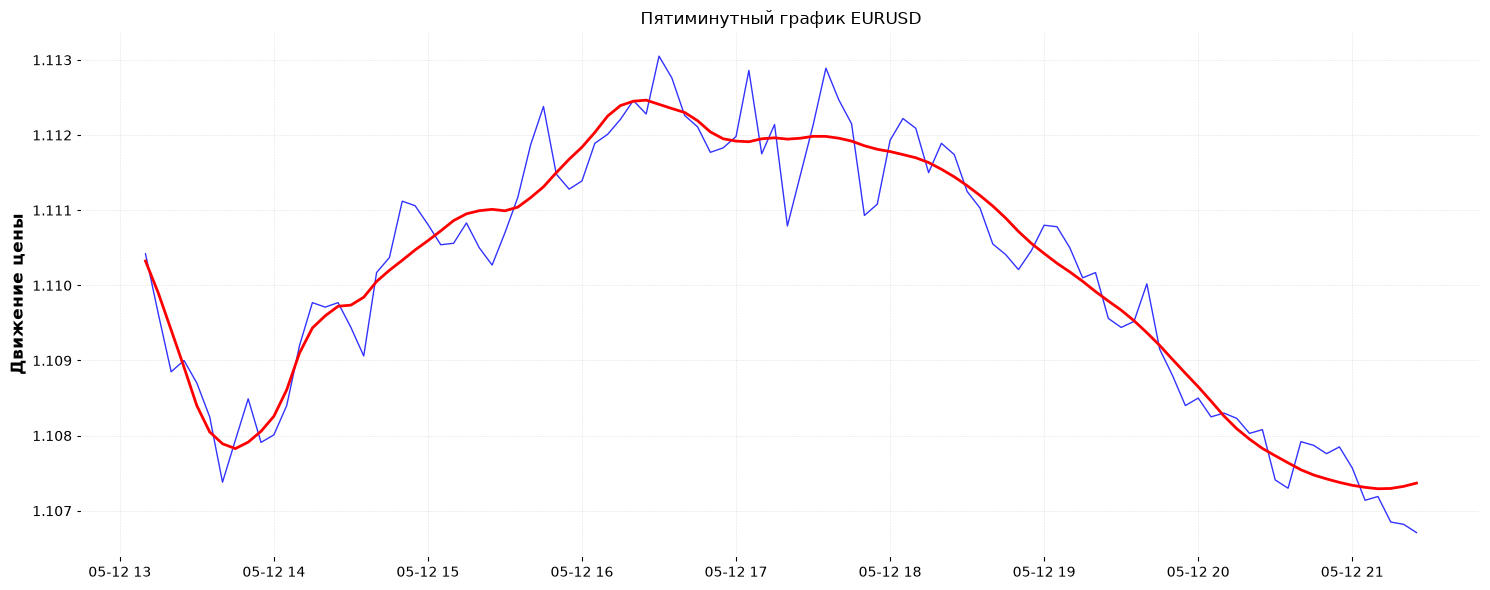

In [72]:
fig, (ax1) = plt.subplots(1, figsize=(15, 6))

# График 1: Временной ряд доходностей
ax1.plot(df['close'].index[:100], df['close'].values[:100], linewidth=1, alpha=0.8, color='blue')
ax1.plot(df['dwt_smooth'].index[:100], df['dwt_smooth'].values[:100], color='red')
ax1.set_title('Пятиминутный график EURUSD')
ax1.set_ylabel('Движение цены')
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Размер обучающей выборки: 79916
Размер тестовой выборки: 19980

Распределение классов в обучающей выборке:
target
 0    40837
-1    19690
 1    19389
Name: count, dtype: int64

Распределение классов в тестовой выборке:
target
 0    12956
-1     3646
 1     3378
Name: count, dtype: int64

Accuracy на тестовой выборке: 0.6484

Classification Report:
                             precision    recall  f1-score   support

    Падение (< -30 пунктов)       0.42      0.01      0.01      3646
Без изменений (±30 пунктов)       0.66      0.98      0.79     12956
        Рост (> 30 пунктов)       0.36      0.06      0.10      3378

                   accuracy                           0.65     19980
                  macro avg       0.48      0.35      0.30     19980
               weighted avg       0.56      0.65      0.53     19980

Confusion Matrix:
[[   20  3479   147]
 [   11 12729   216]
 [   17  3154   207]]

Топ-10 наиболее важных признаков:
             feature  importance
1             

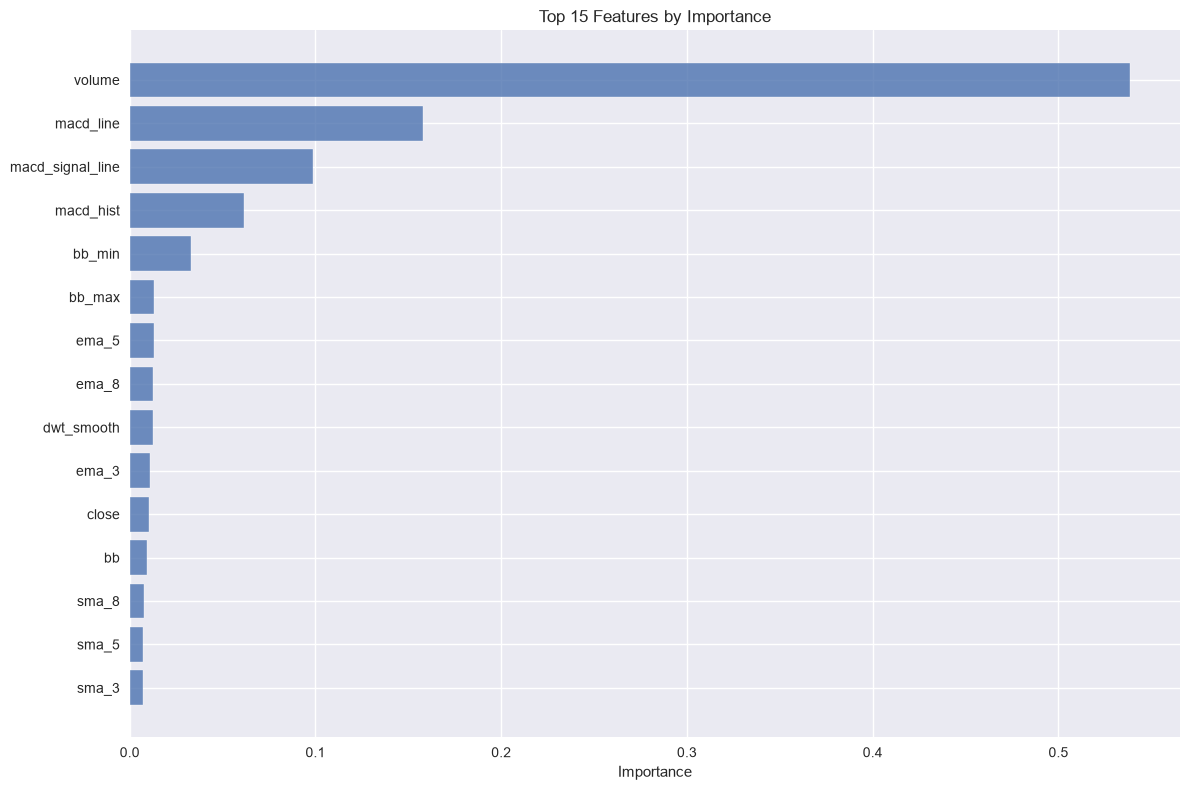

In [68]:
# Обучение RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

# Выбираем признаки для обучения
feature_columns = ['close', 'volume',
                   'sma_3', 'sma_5', 'sma_8',
                   'ema_3', 'ema_5', 'ema_8',
                   'bb_max', 'bb', 'bb_min',
                   'rsi', 'macd_line', 'macd_signal_line', 'macd_hist',
                   'dwt_smooth']

X = df[feature_columns].copy()
y = df['target'].copy()

# Удаляем строки с NaN (если остались после расчёта индикаторов)
X = X.dropna()
y = y.loc[X.index]

# Разделяем данные на обучающую и тестовую выборки (временной порядок)
split_index = int(len(X) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print(f'Размер обучающей выборки: {len(X_train)}')
print(f'Размер тестовой выборки: {len(X_test)}')
print(f'\nРаспределение классов в обучающей выборке:')
print(y_train.value_counts())
print(f'\nРаспределение классов в тестовой выборке:')
print(y_test.value_counts())

# Обучаем RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Предсказания
y_pred = rf_model.predict(X_test)

# Оценка модели
print(f'\nAccuracy на тестовой выборке: {accuracy_score(y_test, y_pred):.4f}')
print(f'\nClassification Report:')
target_names = ['Падение (< -30 пунктов)', 'Без изменений (±30 пунктов)', 'Рост (> 30 пунктов)']
print(classification_report(y_test, y_pred, target_names=target_names))

# Матрица путаницы
print(f'Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))

# Важность признаков
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(f'\nТоп-10 наиболее важных признаков:')
print(feature_importance.head(10))

# Визуализация важности признаков
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'].values, alpha=0.8)
plt.yticks(range(len(top_features)), top_features['feature'].values)
plt.xlabel('Importance')
plt.title('Top 15 Features by Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Total Return: 0.0618 (6.18%)
Sharpe Ratio: 6.6800
Max Drawdown: -0.0156 (-1.56%)


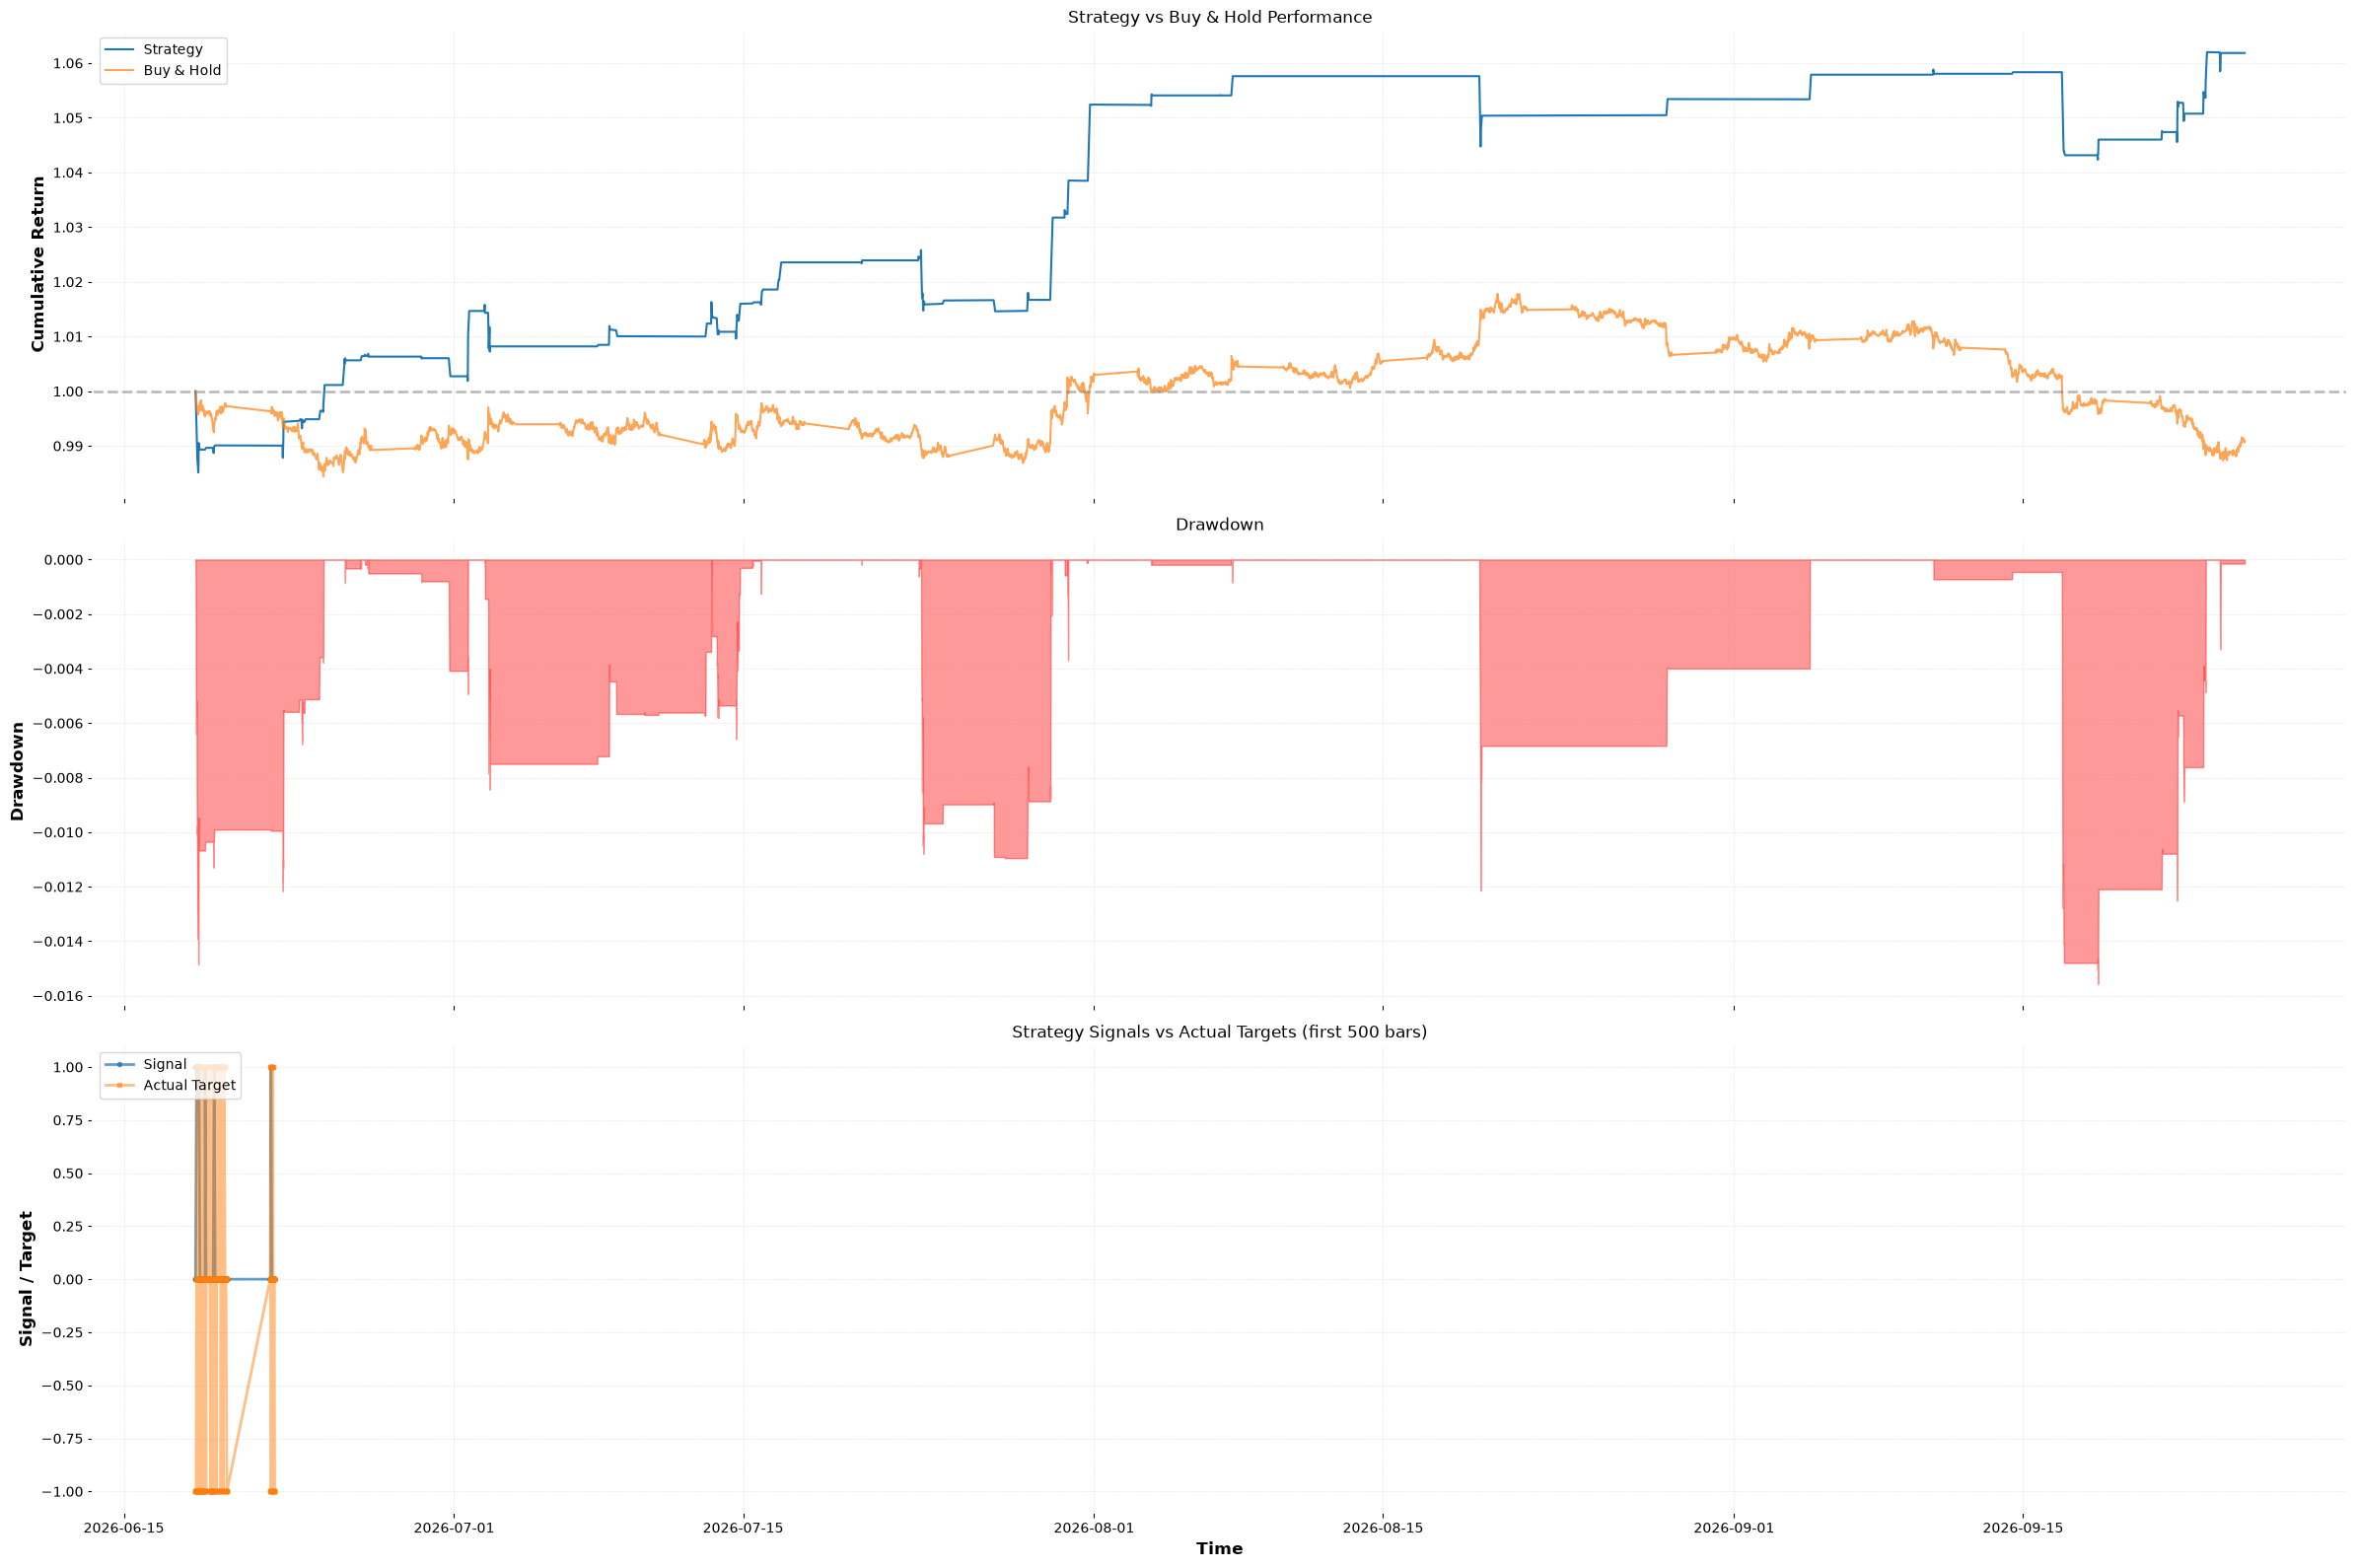

In [71]:
# Оценка торговой стратегии на основе предсказаний модели
# Генерируем сигналы: 1 = длинная позиция, -1 = короткая позиция, 0 = без позиции
signals = np.where(y_pred == 1, 1, np.where(y_pred == -1, -1, 0))

# Вычисляем доходность стратегии
df_test = X_test.copy()
df_test['signals'] = signals
df_test['y_test'] = y_test.values
df_test['predictions'] = y_pred

# Доходность актива
df_test['asset_return'] = df_test['close'].pct_change()

# Доходность стратегии (сигнал * будущая доходность)
# Сдвигаем asset_return на -5, чтобы получить доходность на периоде предсказания
df_test['future_return'] = df_test['close'].shift(-5) / df_test['close'] - 1
df_test['strategy_return'] = df_test['signals'] * df_test['future_return']

# Убираем NaN (последние 5 строк из-за shift(-5))
df_test = df_test.dropna()

# --- Метрики эффективности ---
# Total Return
total_return = (1 + df_test['strategy_return']).prod() - 1
print(f'Total Return: {total_return:.4f} ({total_return*100:.2f}%)')

# Sharpe Ratio (годовой, с учётом M5 = 288 баров в день)
ann_factor = 288 * 252  # 288 свечей в день * 252 торговых дней
sharpe_ratio = (df_test['strategy_return'].mean() / df_test['strategy_return'].std()) * np.sqrt(ann_factor)
print(f'Sharpe Ratio: {sharpe_ratio:.4f}')

# Max Drawdown
cumulative = (1 + df_test['strategy_return']).cumprod()
running_max = cumulative.cummax()
drawdown = (cumulative - running_max) / running_max
max_drawdown = drawdown.min()
print(f'Max Drawdown: {max_drawdown:.4f} ({max_drawdown*100:.2f}%)')

# --- Визуализация результатов ---
fig, axes = plt.subplots(3, 1, figsize=(24, 16), sharex=True)

# График 1:_cumulative доходность
axes[0].plot(cumulative.index, cumulative.values, label='Strategy', linewidth=1.5)
axes[0].plot(cumulative.index, (1 + df_test['asset_return']).cumprod().values, label='Buy & Hold', linewidth=1.5, alpha=0.7)
axes[0].set_ylabel('Cumulative Return')
axes[0].set_title('Strategy vs Buy & Hold Performance')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=1, color='gray', linestyle='--', alpha=0.5)

# График 2: Drawdown
axes[1].fill_between(drawdown.index, drawdown.values, 0, color='red', alpha=0.4)
axes[1].set_ylabel('Drawdown')
axes[1].set_title('Drawdown')
axes[1].grid(True, alpha=0.3)

# График 3: Сигналы стратегии (подвыборка для наглядности)
signals_subset = df_test['signals'].iloc[:500]
pred_subset = df_test['predictions'].iloc[:500]
test_subset = df_test['y_test'].iloc[:500]

axes[2].plot(signals_subset.index, signals_subset.values, label='Signal', marker='o', markersize=3, alpha=0.7)
axes[2].plot(test_subset.index, test_subset.values, label='Actual Target', marker='s', markersize=3, alpha=0.5)
axes[2].set_ylabel('Signal / Target')
axes[2].set_title('Strategy Signals vs Actual Targets (first 500 bars)')
axes[2].legend(loc='upper left')
axes[2].grid(True, alpha=0.3)
axes[2].set_xlabel('Time')

plt.tight_layout()
plt.show()